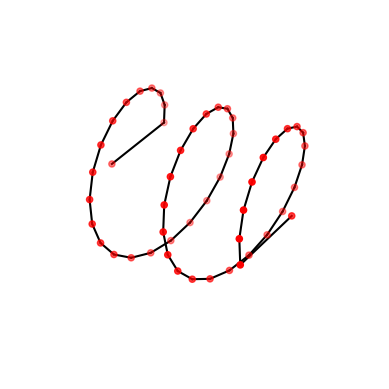

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=1200,
                            youngs_rod=1e9,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=True,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=1,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()

geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')
# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n11.txt')

forces_to_apply = [np.array([120.0, 0.0, 0.0])]

# env.add_force('gravity', g=np.array([10, 0.0, 0.0]))
env.add_force('pointForces', point_force_node_indices=[geo.nodes.shape[0]-1], 
              point_force_vectors=forces_to_apply)
env.add_force('damping', eta=100)

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = np.array([0]) # fix the first node
robot = robot.fix_nodes(fixed_points)
end_force = []
factors = []
def change_pointForces(robot, t):
    #slowly increase the point force over time
    factor = min(t/robot.sim_params.total_time, 1.0)
    robot.env.point_force_vectors = [factor * forces_to_apply[i] for i in range(len(forces_to_apply))]
    
    end_force.append(robot.env.point_force_vectors[0].copy())
    factors.append(factor)
    
    return robot

stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = change_pointForces

In [3]:
robots, t_arr, f_norms = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)

end_force.append(forces_to_apply[0]) # add the final force at the end of the simulation
factors.append(1.0) # add the final factor at the end of the simulation

iter: 1, error: 0.000
current_time:  0.01
iter: 1, error: 1.200
iter: 2, error: 107.652
iter: 3, error: 0.148
current_time:  0.02
iter: 1, error: 1.563
iter: 2, error: 263.679
iter: 3, error: 0.908
iter: 4, error: 0.475
current_time:  0.03
iter: 1, error: 1.880
iter: 2, error: 383.785
iter: 3, error: 1.727
iter: 4, error: 2.331
current_time:  0.04
iter: 1, error: 2.109
iter: 2, error: 407.075
iter: 3, error: 1.724
iter: 4, error: 3.462
current_time:  0.05
iter: 1, error: 2.227
iter: 2, error: 346.464
iter: 3, error: 1.023
iter: 4, error: 2.382
current_time:  0.060000000000000005
iter: 1, error: 2.272
iter: 2, error: 256.193
iter: 3, error: 0.432
iter: 4, error: 1.027
current_time:  0.07
iter: 1, error: 2.305
iter: 2, error: 173.938
iter: 3, error: 0.160
iter: 4, error: 0.373
current_time:  0.08
iter: 1, error: 2.355
iter: 2, error: 113.399
iter: 3, error: 0.077
current_time:  0.09
iter: 1, error: 2.420
iter: 2, error: 73.699
iter: 3, error: 0.045
current_time:  0.09999999999999999
iter

In [4]:
options = dismech.AnimationOptions(title='Helix (N=50)', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

11


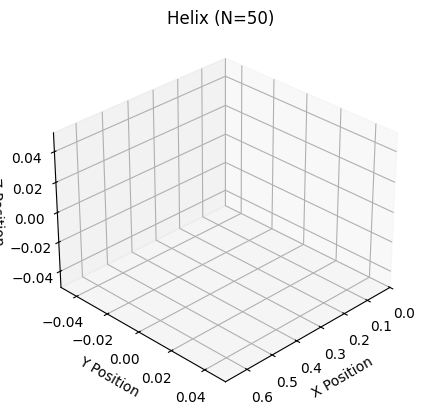

In [5]:
ani = dismech.get_animation(robot, t_arr, qs, options)
ani.save('slinky_pulling.gif')

In [6]:
print(end_force)

[array([0., 0., 0.]), array([1.2, 0. , 0. ]), array([2.4, 0. , 0. ]), array([3.6, 0. , 0. ]), array([4.8, 0. , 0. ]), array([6., 0., 0.]), array([7.2, 0. , 0. ]), array([8.4, 0. , 0. ]), array([9.6, 0. , 0. ]), array([10.8,  0. ,  0. ]), array([12.,  0.,  0.]), array([13.2,  0. ,  0. ]), array([14.4,  0. ,  0. ]), array([15.6,  0. ,  0. ]), array([16.8,  0. ,  0. ]), array([18.,  0.,  0.]), array([19.2,  0. ,  0. ]), array([20.4,  0. ,  0. ]), array([21.6,  0. ,  0. ]), array([22.8,  0. ,  0. ]), array([24.,  0.,  0.]), array([25.2,  0. ,  0. ]), array([26.4,  0. ,  0. ]), array([27.6,  0. ,  0. ]), array([28.8,  0. ,  0. ]), array([30.,  0.,  0.]), array([31.2,  0. ,  0. ]), array([32.4,  0. ,  0. ]), array([33.6,  0. ,  0. ]), array([34.8,  0. ,  0. ]), array([36.,  0.,  0.]), array([37.2,  0. ,  0. ]), array([38.4,  0. ,  0. ]), array([39.6,  0. ,  0. ]), array([40.8,  0. ,  0. ]), array([42.,  0.,  0.]), array([43.2,  0. ,  0. ]), array([44.4,  0. ,  0. ]), array([45.6,  0. ,  0. ]

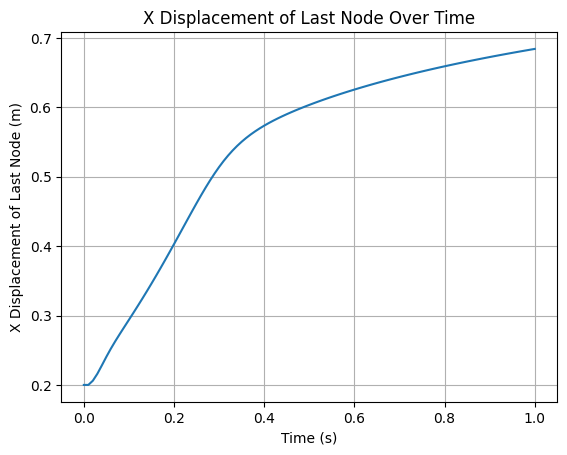

In [7]:
# plot the x discplacement of the last node over time
import matplotlib.pyplot as plt
last_node_x_disp = qs[:, robot.end_node_dof_index-3] # x is the first dof of the last node
plt.plot(t_arr, last_node_x_disp)
plt.xlabel('Time (s)')
plt.ylabel('X Displacement of Last Node (m)')
plt.title('X Displacement of Last Node Over Time')
plt.grid()

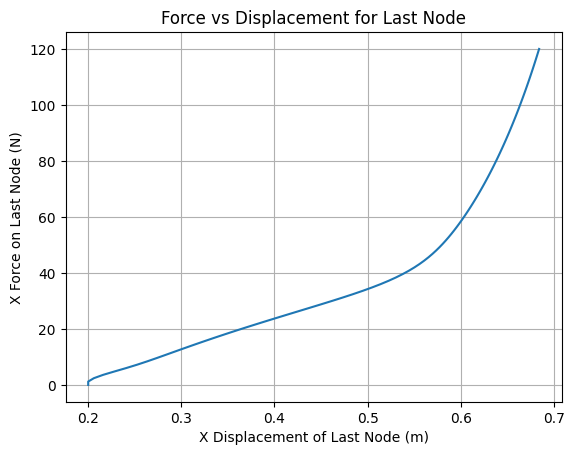

In [8]:
# plot force vs displacement for the last node
plt.figure()
plt.plot(last_node_x_disp, np.array(end_force)[:, 0]) # x component of the force
plt.xlabel('X Displacement of Last Node (m)')
plt.ylabel('X Force on Last Node (N)')
plt.title('Force vs Displacement for Last Node')
plt.grid()
plt.show()

In [9]:
# get training data for HoDEL
T = qs.shape[0]

qs_nodes = qs[:, :robot.n_nodes * 3]
nodes = qs_nodes.reshape(T, robot.n_nodes, 3)

lambda_vals = np.array(factors).reshape(-1,1)

xf_traj = nodes[:, -1, :]   # free DOF trajectory (T,3)

dummy = np.zeros((T,1))     # column HoDEL ignores

train_data = np.hstack([lambda_vals, dummy, xf_traj])

np.savetxt(
    "slinky_pulling_training_data.csv",
    train_data,
    header="lambda,dummy,xf_x,xf_y,xf_z",
    delimiter=",",
    comments=""
)